# CFD data processing
The purpose of this notebook is to process the raw CFD data obtained from a simulation, in order to obtain a clean and organized dataset in the meridional plane $(z,r)$. In the last step we will compute the BFM field, which will be read directly from the Sun instability model

### import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../../')
import Grid

### block and blade objects
instantiate blade and block object in order to generate the bladed domain grid, properly cut at leading and trailing edges of the blade. A more detailed tutorial is available as "camber_surface_vectors.ipynb"

In [16]:
# compute the blade object info, in order to cut the block appropriately
blade = Grid.src.Blade(data_folder_path + 'iris_blade.curve')
blade.find_inlet_points()
blade.find_outlet_points()

# instantiate the bladed domain block object
data_folder_path = '../../Grid/geo/'
units = '[m]'
nstream = 40
nspan = 15
grid_sampling = 'clustering' # type of grid sampling
hub = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_hub.curve', units='m', degree_spline=3)
shroud = Grid.src.Curve(curve_filepath=data_folder_path + 'iris_shroud.curve', units='m', degree_spline=3)
bladed_block = Grid.src.Block(hub, shroud, blade_file=data_folder_path + 'iris_blade.curve', block_type='blade',
                     nstream=nstream, nspan=nspan)

# cut the bladed block properly, and compute the meridional structured mesh
bladed_block.add_inlet_outlet_curves(blade.inlet, blade.outlet)
bladed_block.extend_inlet_outlet_curves()
bladed_block.find_intersections()
bladed_block.bladed_zone_trim()
bladed_block.spline_of_trim()
bladed_block.sample(sampling_mode='clustering')
bladed_block.compute_span_points(sampling_mode='clustering')
bladed_block.compute_double_grid()
bladed_block.find_border()
blade.find_camber_surface(bladed_block)
blade.compute_camber_vectors()

### CFD data object
read the CFD dataset exported from ansys (csv format)

In [3]:
file_name = '../data/iris_85krpm_0.11kgs.csv'
data = Grid.src.CfdData(file_name, rpm_shaft= 85e3, cut_block=bladed_block, blade=blade, verbose=True)

reading CFD data...


### cut the dataset out of the bladed zone
from the whole dataset of the simulation, drop all the points that lie outside the border of the bladed block (this step will take a while since it needs to understand for every point of the CFD if the point lies inside a curvilinear figure). In the same method, the derived quantities in cylindrical cordinates are also obtained starting from the respective ones in cartesian cordinates.

before cutting the domain the situations is the following, where many points exist in the dataset which are out of the bladed domain.

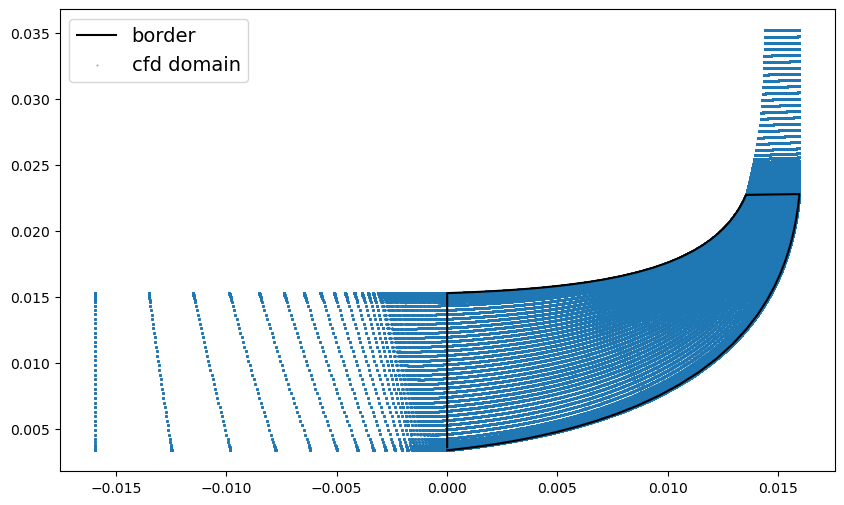

In [4]:
plt.figure(figsize=(10,6))
plt.plot(bladed_block.border[:,0], bladed_block.border[:,1], 'k' ,label='border')
plt.scatter(data.z, data.r, s=0.1, label='dataset points')
plt.legend()
plt.show()

cut the domain with the border information stored in the block object, and process all the data to obtain the derived quantities in cylindrical cordinates

In [5]:
data.process_from_ansys_csv()

cutting domain...


now the situation is the following

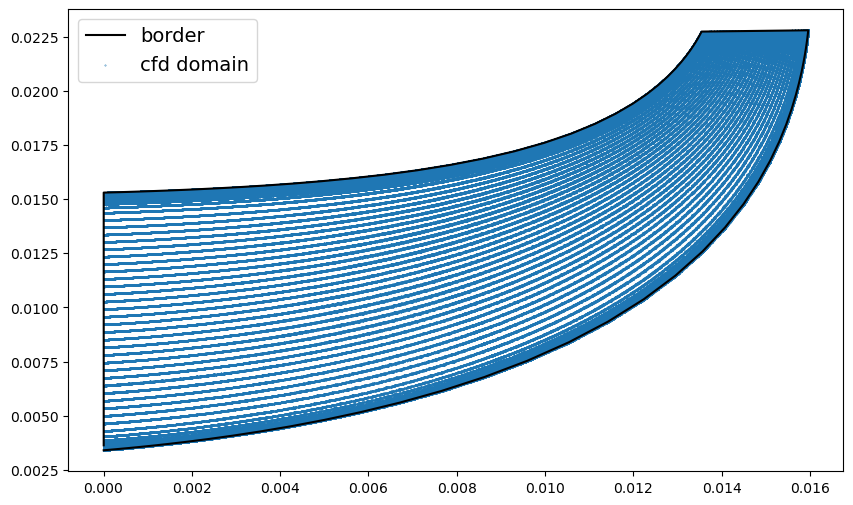

In [6]:
plt.figure(figsize=(10,6))
plt.plot(bladed_block.border[:,0], bladed_block.border[:,1], 'k' ,label='border')
plt.scatter(data.z, data.r, s=0.1, label='cfd domain')
plt.legend()
plt.show()

check for example the 2D projection of the pressure field, sliced every 100 points for simplicity. The field doesn't look nice and smooth, because in the same $(z,r)$ point collapse points from different angular locations. We need to perform still the circumferential averaging

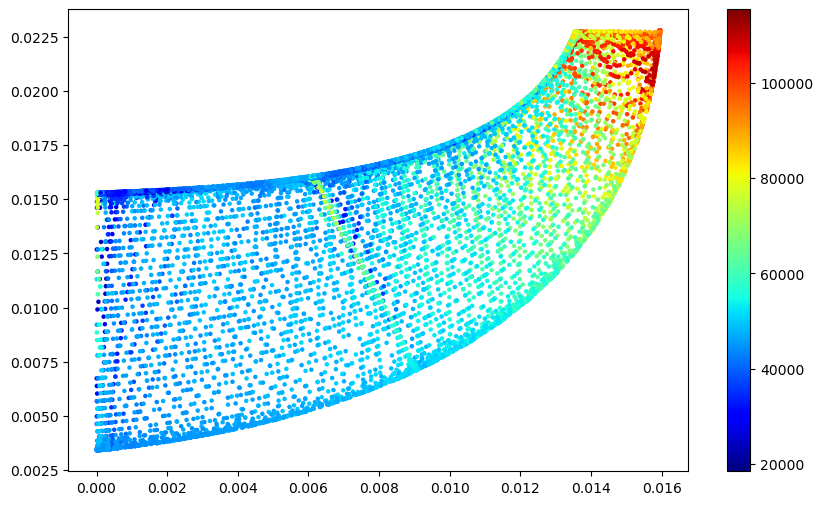

In [18]:
slices = 100
plt.figure(figsize=(10,6))
plt.scatter(data.z[::slices], data.r[::slices], s=5, c=data.p[::slices], cmap='jet')
plt.colorbar()

### compute flow ideal vectors
the ideal flow directions are taken as the direction vectors on the impeller. The flow direction is the oriented streamline on the impeller, while the normal vector is the normal to the camber surface

In [8]:
data.compute_flow_ideal_vectors()

computing flow directions...


### compute the body force model
in the 3D dataset we need to compute $F_{n, \theta} = k u_r \left[ W \tau_{\theta} - (u_{\theta} - \Omega r)\right]$ 
  where:
- $k = \frac{(\partial u_{\theta} / \partial r ) + (u_z / u_r) (\partial u_{\theta} / \partial z) + (u_{\theta} / r)}{W \tau_{\theta} - (u_{\theta} - \Omega r)}$ is a model constant obtained from the tangential momentum equation

- $W$ is the magnitude of the relative velocity
- $\tau_{\theta}$ is the tangential component of the ideal flow direction unity vector
    
    

In [9]:
data.compute_bfm_radial_fields()

### instantiate the meridional object
instantiate a meridional object and perform the circumferential averages

In [10]:
data_process = Grid.src.MeridionalProcess(data, block=bladed_block, blade=blade, verbose=True)
data_process.circumferential_average(mode='gauss filtered', bfm = 'radial')

performing circumferential averages...


check the contour of some fields

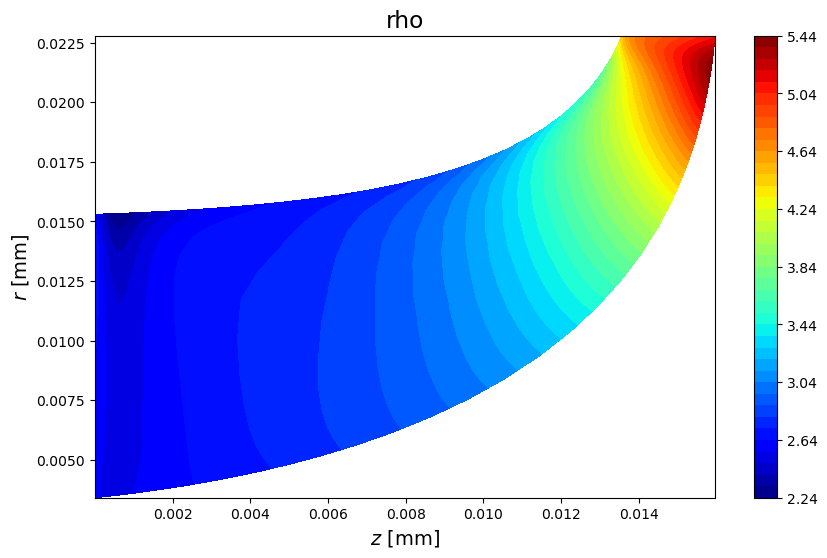

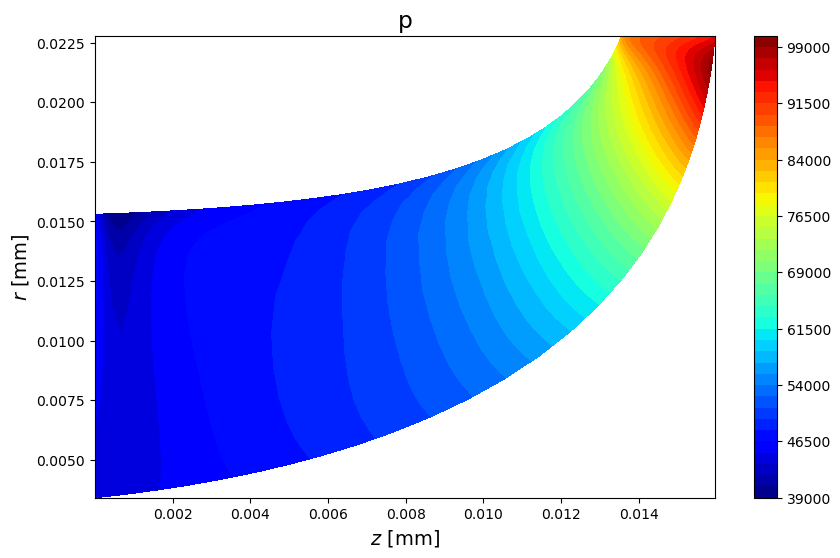

In [11]:
data_process.contour_plot('rho')
data_process.contour_plot('p')

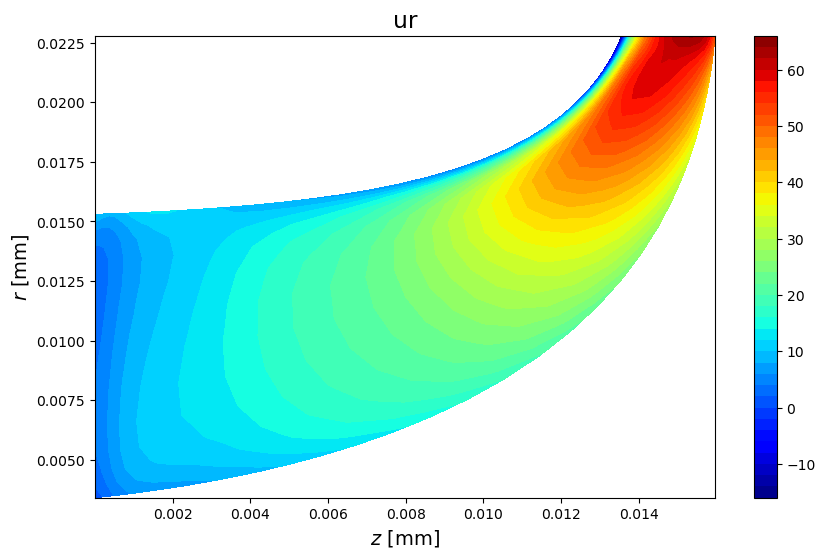

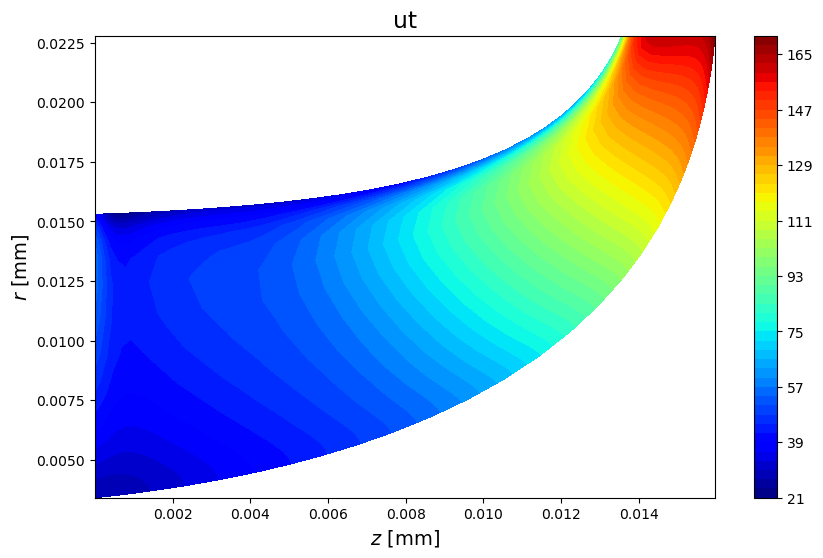

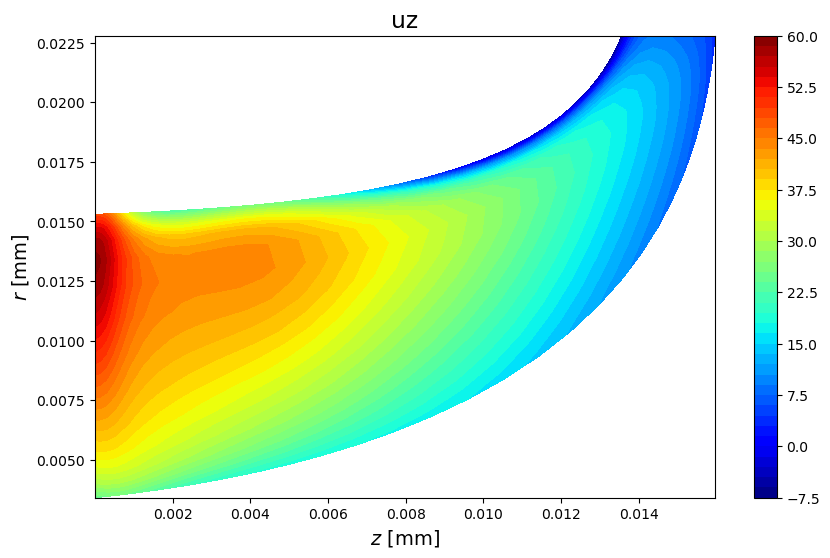

In [12]:
data_process.contour_plot('ur')
data_process.contour_plot('ut')
data_process.contour_plot('uz')

### visualise BFM circumferentially averaged fields
the BFM quantities are calculated on the 3D dataset, and then averaged circumferentially in the same way of the primary fluid dynamic fields.

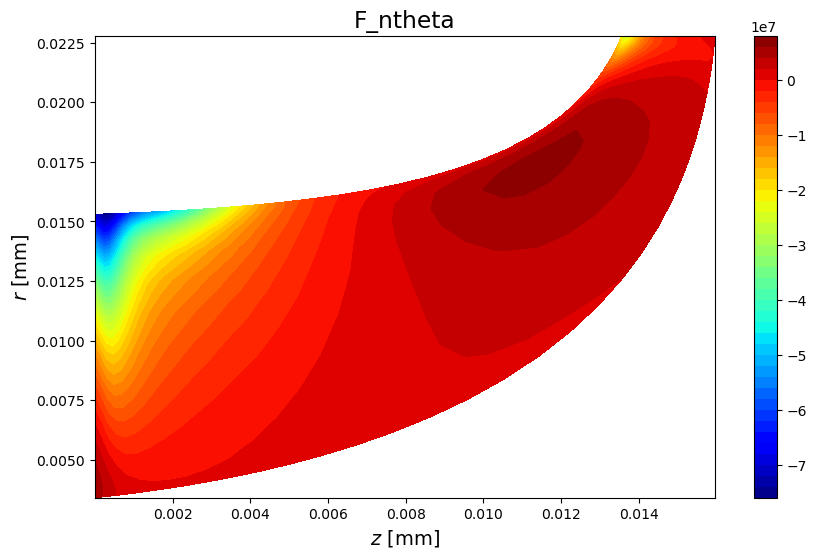

In [13]:
data_process.contour_plot('F_ntheta')

### BFM fields contours
the following quantities are defined in equation (16) of the article Sun et Al. 2016:
- $k_{1} = \frac{(\partial u_{\theta} / \partial r ) + (u_z / u_r) (\partial u_{\theta} / \partial z) + (u_{\theta} / r)}{W \tau_{\theta} - (u_{\theta} - \Omega r)}$ is a model constant obtained from the tangential momentum equation. (Slightly different from $k$ defined earlier)
- $a_1 = k_1 \left[ (U + u^2_r/U)\tau_{\theta} - w_{\theta} \right]$
- $a_2 = k_1 u_r \left[ \frac{w_{\theta}}{U}\tau_{\theta}-1 \right]$
- $\mu = \frac{p_{0,b} - p_{0,a}}{\rho_a (s_b - s_a) U^2_a}$
- $F_t = \mu W^2$

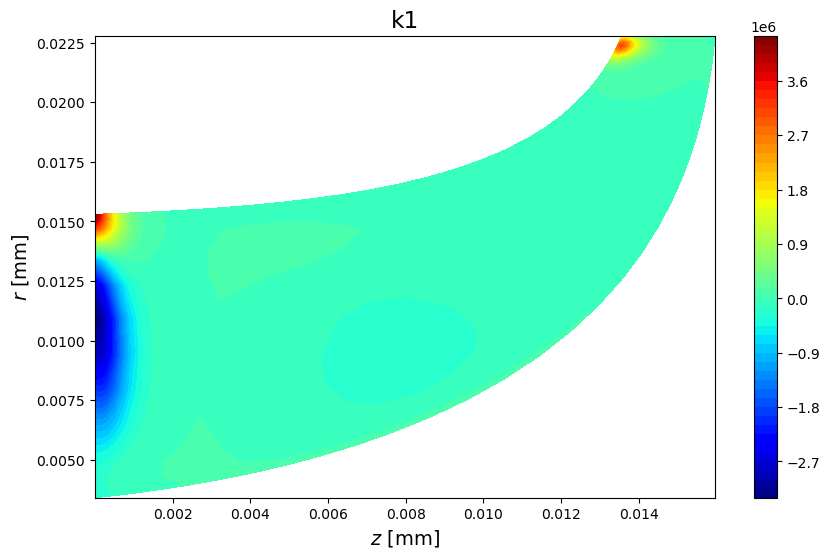

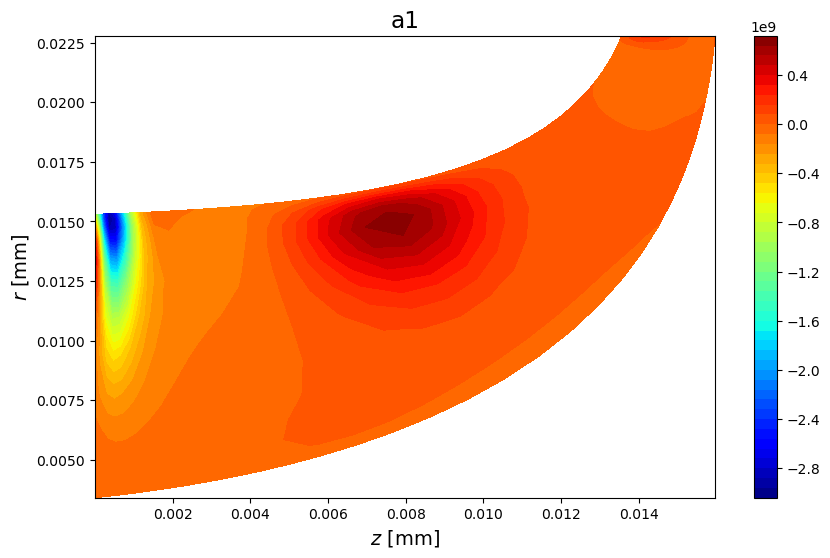

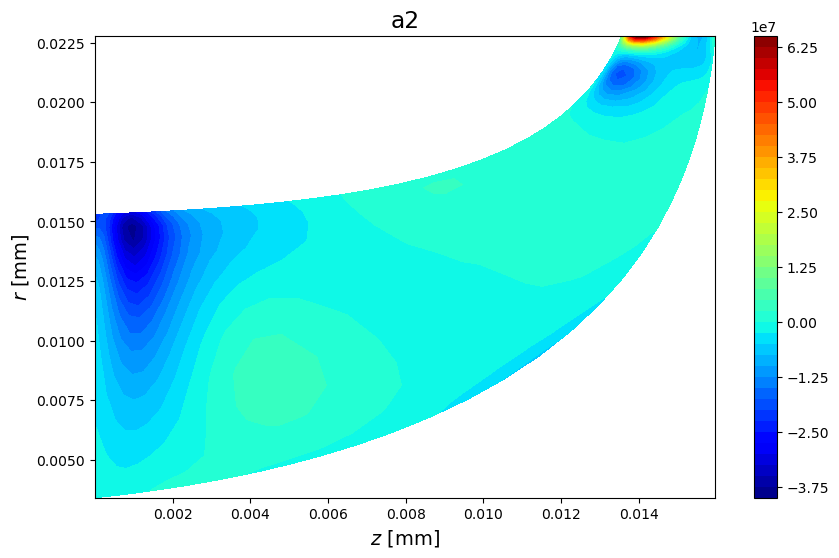

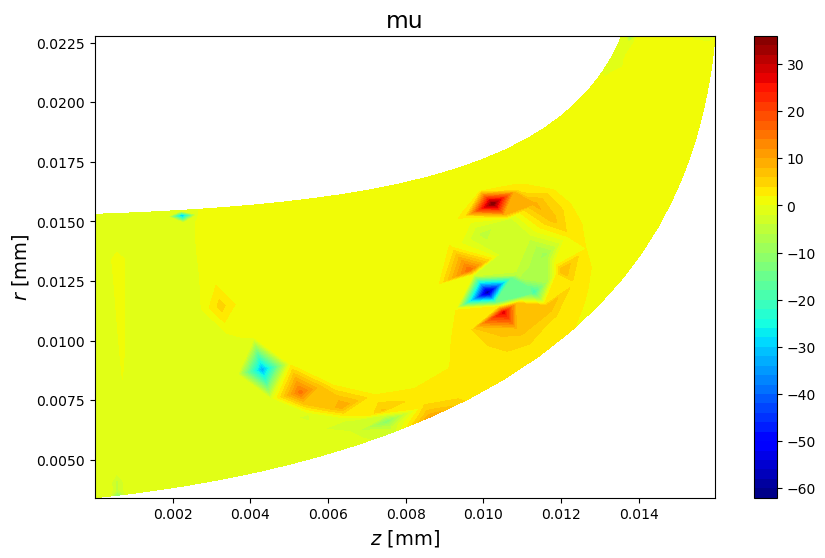

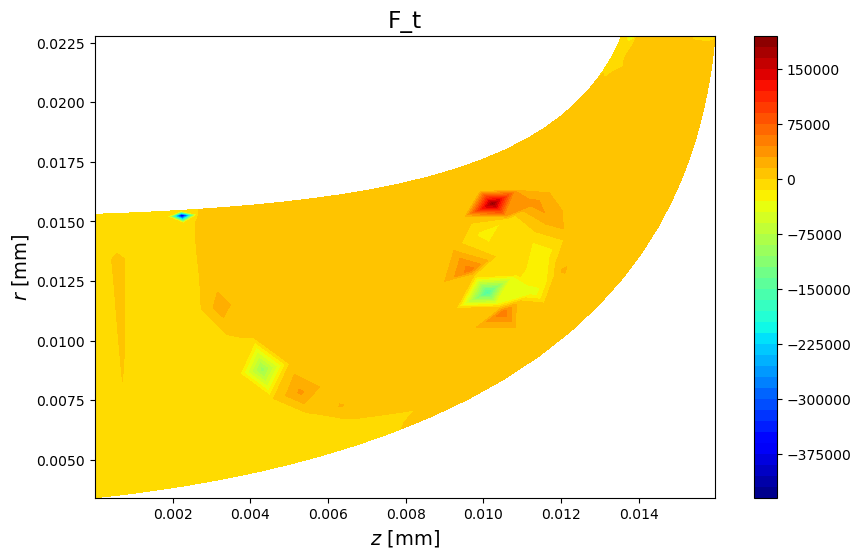

In [20]:
data_process.contour_plot(field='k1')
data_process.contour_plot(field='a1')
data_process.contour_plot(field='a2')
data_process.contour_plot(field='mu')
data_process.contour_plot(field='F_t')